## Convert midi file into pandas dataframe
*same method also works with mido tracks or list of midi messages stored as dictionaries*

In [26]:
import pandas as pd
import mido

# can't iterate directly on midi file
# because it converts ticks to seconds
midi_file = mido.MidiFile('ravel.mid')
df = pd.DataFrame([
    # create a list of dictionaries which can be interpreted by pandas
    message.dict() for message in midi_file.tracks[1] if not message.is_meta
])
df



,type,time,data,control,value,channel,program,note,velocity
0,sysex,0,"[65, 16, 66, 18, 64, 0, 127, 0, 65]",NaN,NaN,NaN,NaN,NaN,NaN
1,sysex,0,"[65, 16, 66, 18, 64, 0, 4, 100, 88]",NaN,NaN,NaN,NaN,NaN,NaN
2,sysex,0,"[65, 16, 66, 18, 64, 1, 48, 3, 12]",NaN,NaN,NaN,NaN,NaN,NaN
3,sysex,0,"[65, 16, 66, 18, 64, 1, 51, 80, 60]",NaN,NaN,NaN,NaN,NaN,NaN
4,sysex,0,"[65, 16, 66, 18, 64, 1, 52, 60, 79]",NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
4137,note_on,2592,NaN,NaN,NaN,0.0,NaN,86.0,0.0
4138,note_on,29,NaN,NaN,NaN,0.0,NaN,79.0,0.0
4139,note_on,7,NaN,NaN,NaN,0.0,NaN,74.0,0.0
4140,control_change,6,NaN,64.0,63.0,0.0,NaN,NaN,NaN


In [ ]:
midi_file


MidiFile(type=1, ticks_per_beat=240, tracks=[
  MidiTrack([
    MetaMessage('set_tempo', tempo=500000, time=0),
    MetaMessage('time_signature', numerator=4, denominator=4, clocks_per_click=24, notated_32nd_notes_per_beat=8, time=0),
    MetaMessage('key_signature', key='G', time=0),
    MetaMessage('track_name', name='\x81@Ravel "Pavane pour une infante defunte"        Play by K.Oguri', time=0),
    MetaMessage('text', text='CVS Ver5.05 Created', time=0),
    MetaMessage('text', text='\x83\x89\x83x\x83\x8b', time=0),
    MetaMessage('text', text='\x81u\x96S\x82«\x89¤\x8f\x97\x82Ì\x88×\x82Ì\x83p\x83\x94\x83@\x81[\x83k\x81v', time=0),
    MetaMessage('text', text='\x89\x89\x91t\x81@\x81@\x8f¬\x8cI\x8d\x8e\x97T', time=0),
    MetaMessage('end_of_track', time=0)]),
  MidiTrack([
    MetaMessage('track_name', name='PIANO', time=0),
    MetaMessage('midi_port', port=0, time=0),
    MetaMessage('text', text='<RESET>', time=0),
    Message('sysex', data=(65, 16, 66, 18, 64, 0, 127, 0, 65), t

## Wrangle dataframe

In [28]:
import numpy as np
from sklearn.impute import KNNImputer


# create a category type which enumarates labels in user defined order
type_names = ['note_on', 'note_off', 'control_change']
cat_type = pd.CategoricalDtype(type_names, ordered=True)
# create a new series with the category codes in new variable
wrangled_df = df[df['type'] != 'sysex']
wrangled_df['type_codes'] = df['type'].astype(cat_type).cat.codes

# create a new series with shifted codes to use next code
# as current code and predict future
wrangled_df = wrangled_df.drop(['type', 'channel', 'program', 'data'], axis=1)
wrangled_df = pd.concat(
    # TODO check if it makes sense to use imputer 
    # instead of simple value replacement
    [wrangled_df, wrangled_df.shift(-1).add_prefix('next_')], axis=1
).drop(wrangled_df.tail(1).index)

imputer = KNNImputer(n_neighbors=2)
imputed_array = imputer.fit_transform(wrangled_df)
imputed_df = pd.DataFrame(imputed_array, columns=wrangled_df.columns).astype('int')

imputed_df



/var/folders/33/wgwlkyg527v5hnsfct930frm0000gn/T/ipykernel_78044/2163133732.py:10: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  wrangled_df['type_codes'] = df['type'].astype(cat_type).cat.codes


,time,control,value,note,velocity,type_codes,next_time,next_control,next_value,next_note,next_velocity,next_type_codes
0,192,0,0,44,0,2,2,32,1,50,0,2
1,2,32,1,62,79,2,2,64,63,61,68,-1
2,2,64,127,67,34,-1,98,7,100,69,0,2
3,98,7,100,54,0,2,96,11,80,61,74,2
4,96,11,80,54,0,2,96,10,64,61,74,2
...,...,...,...,...,...,...,...,...,...,...,...,...
4131,11,65,127,55,0,0,2592,65,95,86,0,0
4132,2592,64,63,86,0,0,29,64,95,79,0,0
4133,29,64,63,79,0,0,7,64,95,74,0,0
4134,7,64,0,74,0,0,6,64,63,71,0,2


In [29]:
wrangled_df.to_csv('satie_wrangled.csv')


## Create actual training data tables

In [30]:
# exclude second half of columns ('next_' values)
data = imputed_df.iloc[:,:int(imputed_array.shape[1] / 2)]
# take column to use as target for predictions
target = imputed_df['next_type_codes']


## Train KNN model for msg type parameter and test for accuracy
*KNN does support multioutput classification (not regression) but it's accuracy evaluation method does not*

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
# import SimpleImputer to replace NaN because not accepted in KNN
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 20)

# test different settings
for n_neighbors in neighbors_settings:
    type_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    type_knn.fit(X_train, y_train)
    training_accuracy.append(type_knn.score(X_train, y_train))
    test_accuracy.append(type_knn.score(X_test, y_test))

# use best setting
ratios = []
i = 0
for x in training_accuracy:
    if training_accuracy[i] != 0:
        ratios.append(test_accuracy[i] / training_accuracy[i])
        i += 1

highest_score_index = ratios.index(max(ratios)) + 1
print(f'best score: {ratios.index(max(ratios)) + 1}')
type_knn = KNeighborsClassifier(n_neighbors=highest_score_index)
type_knn.fit(X_train, y_train)

type_knn.predict(X_test).astype('int')


best score: 18


array([0, 0, 0, ..., 0, 0, 0], shape=(1034,))

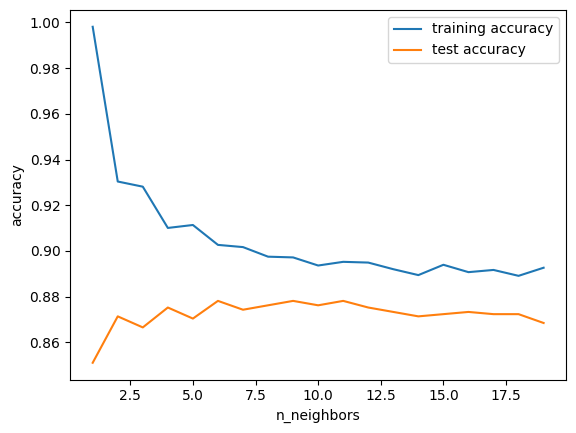

In [32]:
# plotting
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Create data table to predict next parameter (Note value)

In [33]:
# exclude second half of columns ('next_' values)
data = imputed_df.iloc[:,:int(imputed_array.shape[1] / 2)]
# but include next_type_codes to use the generated 
# data point for next_type_codes to predict next_note
data['next_type_codes'] = imputed_df['next_type_codes']
# take column to use as target for predictions
target = imputed_df['next_note']


## Train KNN model for note number parameter and test for accuracy

In [34]:
X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 20)

# test different settings
for n_neighbors in neighbors_settings:
    note_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    note_knn.fit(X_train, y_train)
    training_accuracy.append(note_knn.score(X_train, y_train))
    test_accuracy.append(note_knn.score(X_test, y_test))

# use best setting
ratios = []
i = 0
for x in training_accuracy:
    if training_accuracy[i] != 0:
        ratios.append(test_accuracy[i] / training_accuracy[i])
        i += 1

highest_score_index = ratios.index(max(ratios)) + 1
print(f'best score: {ratios.index(max(ratios)) + 1}')
note_knn = KNeighborsClassifier(n_neighbors=highest_score_index)
note_knn.fit(X_train, y_train)

note_knn.predict(X_test).astype('int')


best score: 19


array([43, 52, 62, ..., 60, 74, 59], shape=(1034,))

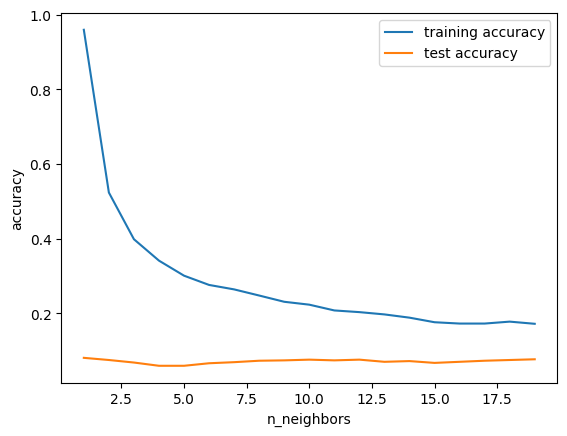

In [35]:
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Create data table to predict next parameter (Note velocity)

In [36]:
# exclude second half of columns ('next_' values)
data = imputed_df.iloc[:,:int(imputed_array.shape[1] / 2)]
# but include next_type_codes to use the generated 
# data point for next_type_codes to predict next_note
data[['next_type_codes', 'next_note']] = imputed_df[['next_type_codes', 'next_note']]
# take column to use as target for predictions
target = imputed_df['next_velocity']


## Train KNN model for note velocity parameter and test for accuracy

In [37]:
from sklearn.neighbors import KNeighborsRegressor

X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 20)

# test different settings
for n_neighbors in neighbors_settings:
    velocity_knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    velocity_knn.fit(X_train, y_train)
    training_accuracy.append(velocity_knn.score(X_train, y_train))
    test_accuracy.append(velocity_knn.score(X_test, y_test))

# use best setting
ratios = []
i = 0
for x in training_accuracy:
    if training_accuracy[i] != 0:
        ratios.append(test_accuracy[i] / training_accuracy[i])
        i += 1

highest_score_index = ratios.index(max(ratios)) + 1
print(f'best score: {ratios.index(max(ratios)) + 1}')
velocity_knn = KNeighborsRegressor(n_neighbors=highest_score_index)
velocity_knn.fit(X_train, y_train)

velocity_knn.predict(X_test).astype('int')


best score: 19


array([30, 29, 39, ..., 25, 64,  5], shape=(1034,))

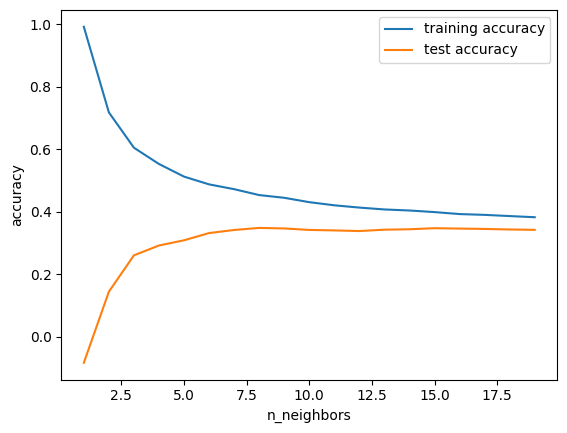

In [38]:
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Create data table to predict next parameter (cc number)

In [39]:
# exclude second half of columns ('next_' values)
data = imputed_df.iloc[:,:int(imputed_array.shape[1] / 2)]
# but include next_type_codes to use the generated 
# data point for next_type_codes to predict next_note
data['next_type_codes'] = imputed_df['next_type_codes']
# take column to use as target for predictions
target = imputed_df['next_control']


## Train KNN model for note number parameter and test for accuracy

In [40]:
X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 20)

# test different settings
for n_neighbors in neighbors_settings:
    control_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    control_knn.fit(X_train, y_train)
    training_accuracy.append(control_knn.score(X_train, y_train))
    test_accuracy.append(control_knn.score(X_test, y_test))

# use best setting
ratios = []
i = 0
for x in training_accuracy:
    if training_accuracy[i] != 0:
        ratios.append(test_accuracy[i] / training_accuracy[i])
        i += 1

highest_score_index = ratios.index(max(ratios)) + 1
print(f'best score: {ratios.index(max(ratios)) + 1}')
control_knn = KNeighborsClassifier(n_neighbors=highest_score_index)
control_knn.fit(X_train, y_train)

control_knn.predict(X_test).astype('int')


best score: 19


array([64, 64, 64, ..., 64, 64, 64], shape=(1034,))

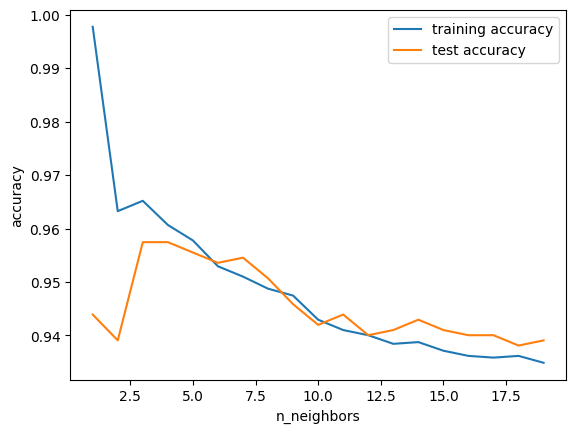

In [41]:
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Create data table to predict next parameter (cc number)

In [42]:
# exclude second half of columns ('next_' values)
data = imputed_df.iloc[:,:int(imputed_array.shape[1] / 2)]
# but include next_type_codes to use the generated 
# data point for next_type_codes to predict next_note
data[['next_type_codes', 'next_control']] = imputed_df[['next_type_codes', 'next_control']]
# take column to use as target for predictions
target = imputed_df['next_value']


## Train KNN model for note number parameter and test for accuracy

In [43]:
X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 20)

# test different settings
for n_neighbors in neighbors_settings:
    value_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    value_knn.fit(X_train, y_train)
    training_accuracy.append(value_knn.score(X_train, y_train))
    test_accuracy.append(value_knn.score(X_test, y_test))

# use best setting
ratios = []
i = 0
for x in training_accuracy:
    if training_accuracy[i] != 0:
        ratios.append(test_accuracy[i] / training_accuracy[i])
        i += 1

highest_score_index = ratios.index(max(ratios)) + 1
print(f'best score: {ratios.index(max(ratios)) + 1}')
value_knn = KNeighborsClassifier(n_neighbors=highest_score_index)
value_knn.fit(X_train, y_train)

value_knn.predict(X_test).astype('int')


best score: 19


array([ 95, 127,  63, ...,  63,  72, 127], shape=(1034,))

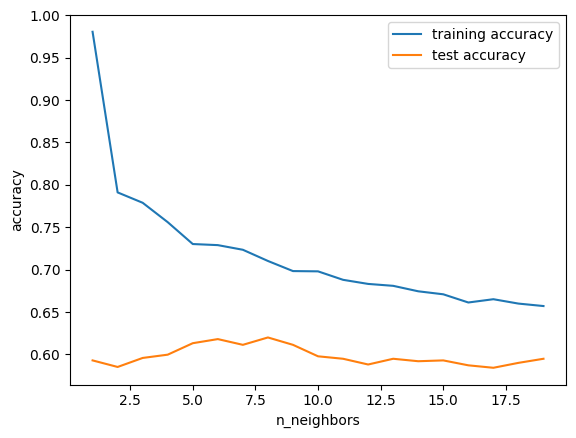

In [44]:
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Create data table to predict next parameter (time)

In [45]:
# exclude second half of columns ('next_' values)
data = imputed_df.drop('next_time', axis=1)
# take column to use as target for predictions
target = imputed_df['next_time']


## Train KNN model for note number parameter and test for accuracy

In [46]:
X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 20)

# test different settings
for n_neighbors in neighbors_settings:
    time_knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    time_knn.fit(X_train, y_train)
    training_accuracy.append(time_knn.score(X_train, y_train))
    test_accuracy.append(time_knn.score(X_test, y_test))

# use best setting
ratios = []
i = 0
for x in training_accuracy:
    if training_accuracy[i] != 0:
        ratios.append(test_accuracy[i] / training_accuracy[i])
        i += 1

highest_score_index = ratios.index(max(ratios)) + 1
print(f'best score: {ratios.index(max(ratios)) + 1}')
time_knn = KNeighborsRegressor(n_neighbors=highest_score_index)
time_knn.fit(X_train, y_train)

time_knn.predict(X_test).astype('int')


best score: 19


array([ 0,  3, 58, ..., 82, 17, 48], shape=(1034,))

In [47]:
X_train


,time,control,value,note,velocity,type_codes,next_control,next_value,next_note,next_velocity,next_type_codes
2452,3,64,31,43,0,0,64,95,58,0,0
2899,2,48,32,65,109,0,35,31,69,104,0
1617,5,64,127,62,51,0,64,63,67,0,0
3178,5,64,0,76,61,2,64,63,70,0,2
2020,1,64,63,50,0,0,64,0,78,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1411,1,64,63,53,0,0,64,0,55,0,0
4080,7,64,0,57,0,0,64,63,43,125,0
2877,7,64,63,57,90,0,64,0,60,93,0
1882,1,48,32,72,90,0,35,31,60,81,0


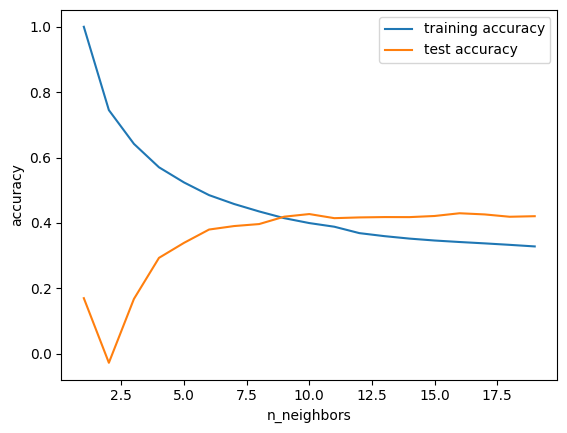

In [48]:
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Making complete prediction

In [ ]:
import mido
from sklearn.utils import shuffle

midi_file = mido.MidiFile(ticks_per_beat=240)
midi_track = mido.MidiTrack()
midi_file.tracks.append(midi_track)
generated_msgs = []

# initialize
i = 0
random = np.random.randint(1, 20)
X_start = imputed_df.iloc[:1,:int(imputed_array.shape[1] / 2)]
print(X_start)
for x in range(20000):
    if i == random:
        X_start = imputed_df.iloc[[np.random.choice(imputed_df.shape[0])], :int(imputed_array.shape[1] / 2)]
        random = np.random.randint(1, 20)
        i = 0
    i += 1 
    X_new = X_start.copy()
    new_type = type_knn.predict(X_start).squeeze()
    X_new['next_type_codes'] = new_type
    new_control = control_knn.predict(X_new).squeeze()
    X_new['next_control'] = new_control
    new_value = value_knn.predict(X_new).squeeze()
    X_new.drop('next_control', axis=1, inplace=True)
    new_note = note_knn.predict(X_new).squeeze()
    X_new['next_note'] = new_note
    new_velocity = velocity_knn.predict(X_new).squeeze()
    X_new['next_velocity'] = new_velocity
    X_new['next_control'] = new_control
    X_new['next_value'] = new_value
    X_new.drop('next_type_codes', axis=1, inplace=True)
    X_new['next_type_codes'] = new_type
    # Reorder columns for time_knn input
    time_knn_input_order = [
        'time', 'control', 'value', 'note', 'velocity', 'type_codes',
        'next_control', 'next_value', 'next_note', 'next_velocity', 'next_type_codes'
    ]
    X_time_input = X_new[time_knn_input_order]
    new_time = time_knn.predict(X_time_input).squeeze()
    X_new['next_time'] = new_time
    X_new = X_new.iloc[:,int(imputed_array.shape[1] / 2):]
    X_new.columns = X_new.columns.str.removeprefix('next_')

    for col in X_start.columns:
        X_start[col] = X_new[col]

    new_msg = X_new.astype('int')
    new_msg['type'] = type_names[new_msg['type_codes'].iloc[-1]]
    new_msg.drop('type_codes', axis=1, inplace=True)
    new_msg = new_msg.to_dict(orient='records')[0]
    if new_msg['type'] in ['note_on', 'note_off']:
        new_msg.pop('control', None)
        new_msg.pop('value', None)
    elif new_msg['type'] == 'control_change':
        new_msg.pop('note', None)
        new_msg.pop('velocity', None)

    generated_msgs.append(new_msg.copy())

    midi_track.append(mido.Message(**new_msg))

midi_file.save('b.mid')
df_generated = pd.DataFrame(generated_msgs)
df_generated.to_csv('generated_messages.csv')


   time  control  value  note  velocity  type_codes
0   192        0      0    44         0           2


In [50]:

new_message = {
    'type': type_names[new_type]
}
new_message


{'type': 'note_on'}